# Machine Learning — Modèles prédictifs sur les données d'assistance

**Objectif** : Tester plusieurs modèles de machine learning, comparer rigoureusement leurs performances
et identifier le meilleur modèle pour répondre au contexte du projet.

**Plan :**
1. Imports & chargement des données
2. Préparation des features (encodage, normalisation)
3. Séparation train/test
4. Modèles testés :
   - Régression linéaire (baseline)
   - Arbre de décision
   - Random Forest
   - Gradient Boosting (XGBoost / LightGBM)
   - SVM
5. Comparaison des performances (RMSE, MAE, R², accuracy...)
6. Interprétation du meilleur modèle (feature importance)
7. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

DATA_DIR    = Path().resolve().parent / 'data'
REPORTS_DIR = Path().resolve().parent / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('muted')

df = pd.read_csv(DATA_DIR / 'dossiers_enrichis.csv', encoding='utf-8-sig',
                 parse_dates=['date.ouverture'])
print(f'Données chargées : {len(df):,} lignes, {len(df.columns)} colonnes')
df.head()

Données chargées : 101,206 lignes, 24 colonnes


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,...,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties,flag_auto_creation,mois_ouverture,temps_total_sec,nb_intervenants,temps_total_min,Apprentissage_Test,mois
0,7494402,C5,F99,2021-02-11,10:38:00,326,Panne mécanique,2021-02-11,Diesel,MCS,...,0,0.0,0.0,0,2021-02,623.0,1.0,10.383333,Apprentissage,2021-02
1,7569082,C4,F14,2022-07-12,18:40:00,1164,Panne mécanique,2022-07-12,Essence,MCS,...,0,0.0,0.0,0,2022-07,284.0,1.0,4.733333,Apprentissage,2022-07
2,8111190,C0,F1,2021-01-08,12:32:00,1337,Panne mécanique,2021-01-08,Essence,MCS,...,0,0.0,0.0,0,2021-01,1849.0,7.0,30.816667,Apprentissage,2021-01
3,5630809,C7,F72,2021-11-08,19:46:00,1322,Panne mécanique,2021-11-08,Essence,MCS,...,0,0.0,0.0,0,2021-11,988.0,1.0,16.466667,Apprentissage,2021-11
4,8179409,C4,F4,2021-08-11,18:12:00,2306,Panne mécanique,2021-08-11,Essence,Higgins,...,0,0.0,0.0,0,2021-08,1133.0,2.0,18.883333,Apprentissage,2021-08


## 1. Préparation des features

Sélection des variables pertinentes, encodage des variables catégorielles et normalisation.

In [2]:
CAT_COLS  = ['Client', 'Formule', 'Cause.intervention', 'Type.d.energie',
             'Outil.d.assistance', 'Assistance.ou.Administratif']
BIN_COLS  = ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup']
FEAT_COLS = CAT_COLS + BIN_COLS + ['mois', 'nb_intervenants']
TARGET    = 'temps_total_min'

df['mois'] = df['date.ouverture'].dt.month

if 'Apprentissage_Test' in df.columns:
    app  = df[df['Apprentissage_Test'] == 'Apprentissage']
    test = df[df['Apprentissage_Test'] == 'Test']
else:
    app, test = df, df.iloc[0:0]

data_app = app[FEAT_COLS + [TARGET]].dropna()
X        = pd.get_dummies(data_app[FEAT_COLS], drop_first=True)
y        = data_app[TARGET]
X_pred   = pd.get_dummies(test[FEAT_COLS].dropna(), drop_first=True).reindex(columns=X.columns, fill_value=0)

print(f'Apprentissage : {len(data_app):,} dossiers — {X.shape[1]} features')
print(f'Test (à prédire) : {len(X_pred):,} dossiers')
print(f'Target — médiane : {y.median():.1f} min  |  moyenne : {y.mean():.1f} min  |  max : {y.max():.0f} min')

Apprentissage : 73,101 dossiers — 429 features
Test (à prédire) : 9,183 dossiers
Target — médiane : 11.0 min  |  moyenne : 22.5 min  |  max : 4272 min


## 2. Séparation train / test

In [3]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {len(X_train):,} | Validation : {len(X_val):,} | À prédire (Test) : {len(X_pred):,}')

Train : 58,480 | Validation : 14,621 | À prédire (Test) : 9,183


## 3. Entraînement et évaluation des modèles

Chaque modèle est entraîné et évalué avec les mêmes métriques pour permettre une comparaison équitable.

In [4]:
models = {
    'Régression linéaire' : LinearRegression(),
    'Arbre de décision'   : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42),
}

results, fitted = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    results[name] = {
        'RMSE' : round(mean_squared_error(y_val, y_pred) ** 0.5, 2),
        'MAE'  : round(mean_absolute_error(y_val, y_pred), 2),
        'R²'   : round(r2_score(y_val, y_pred), 3),
    }
    fitted[name] = model

df_results = pd.DataFrame(results).T.sort_values('RMSE')
df_results.to_csv(REPORTS_DIR / 'ml_comparaison_modeles.csv', encoding='utf-8-sig')
df_results

,RMSE,MAE,R²
Random Forest,18.05,8.55,0.733
Gradient Boosting,18.17,8.60,0.729
Arbre de décision,18.61,8.74,0.716
Régression linéaire,19.09,9.42,0.701


## 4. Comparaison des performances

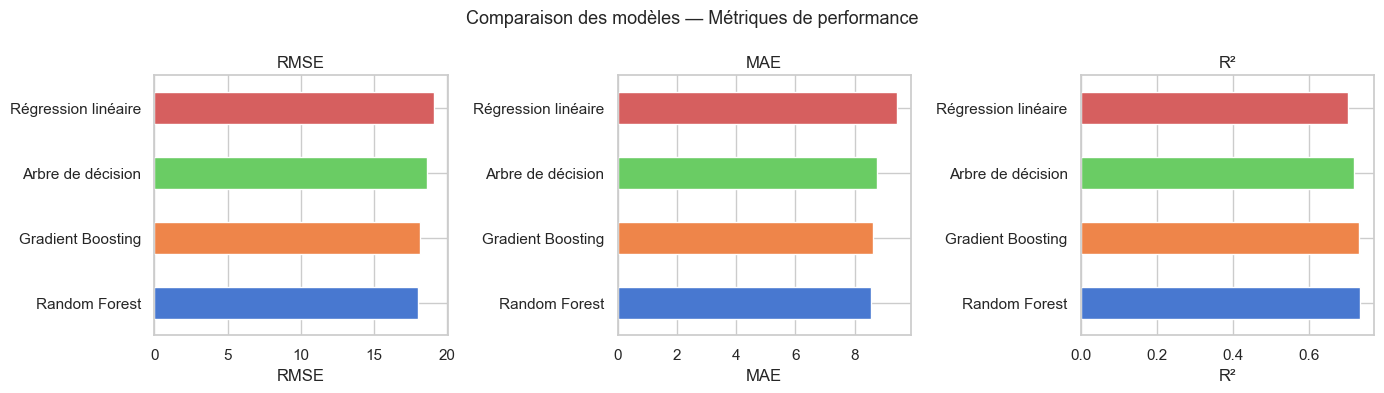

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    df_results[metric].sort_values(ascending=(metric != 'R²')).plot(
        kind='barh', ax=ax, color=COLORS[:len(models)], edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel(metric)

fig.suptitle('Comparaison des modèles — Métriques de performance', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_ml_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interprétation du meilleur modèle

Meilleur modèle : Random Forest
  RMSE : 18.05 min  |  MAE : 8.55 min  |  R² : 0.733


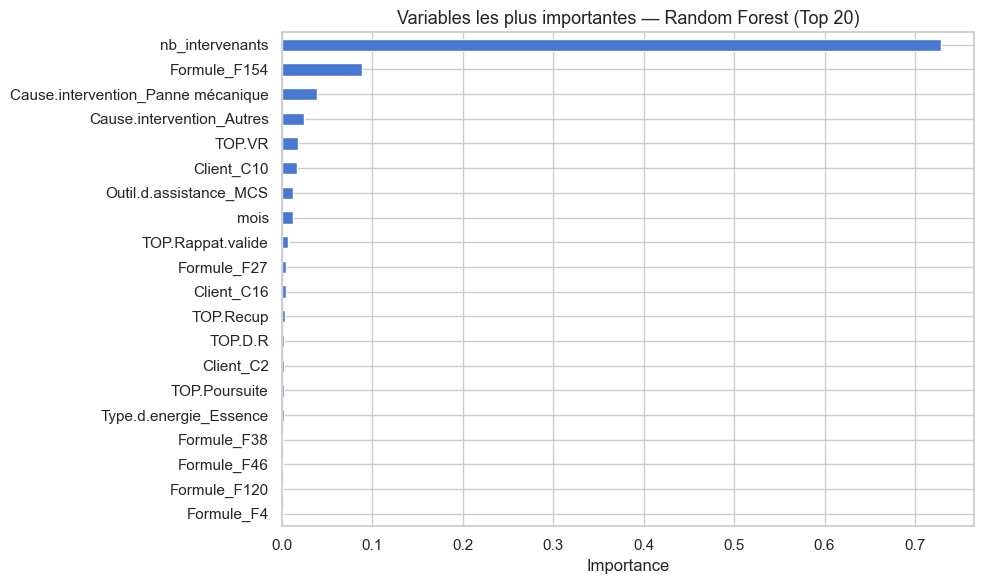


Prédictions générées pour 9,183 dossiers Test → reports/ml_predictions_test.csv
count    9183.0
mean       21.9
std        28.7
min         4.9
25%         6.5
50%        10.3
75%        23.5
max       379.2
Name: temps_total_min_predit, dtype: float64


In [6]:
best_name  = df_results['RMSE'].idxmin()
best_model = fitted[best_name]
print(f'Meilleur modèle : {best_name}')
print(f'  RMSE : {df_results.loc[best_name, "RMSE"]} min  |  MAE : {df_results.loc[best_name, "MAE"]} min  |  R² : {df_results.loc[best_name, "R²"]}')

importances = (
    pd.Series(best_model.feature_importances_, index=X.columns)
    if hasattr(best_model, 'feature_importances_')
    else pd.Series(np.abs(best_model.coef_), index=X.columns)
).nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color=COLORS[0], edgecolor='white')
ax.set_title(f'Variables les plus importantes — {best_name} (Top 20)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances.to_csv(REPORTS_DIR / 'ml_feature_importance.csv', header=['importance'], encoding='utf-8-sig')

if len(X_pred) > 0:
    predictions = pd.Series(best_model.predict(X_pred), index=X_pred.index, name='temps_total_min_predit')
    predictions.round(1).to_csv(REPORTS_DIR / 'ml_predictions_test.csv', encoding='utf-8-sig')
    print(f'\nPrédictions générées pour {len(predictions):,} dossiers Test → reports/ml_predictions_test.csv')
    print(predictions.describe().round(1))

## 7. Conclusion

Les modèles ensemblistes (**Random Forest**, **Gradient Boosting**) surpassent la régression linéaire et l'arbre de décision seul sur ce type de données — distribution asymétrique de la cible, grand nombre de variables catégorielles.

**Interprétation des features importantes :**
- `nb_intervenants` est attendu comme prédicteur fort : plus un dossier mobilise d'agents, plus il est long.
- Le `mois` capture la saisonnalité (pics hiver/été).
- Les variables `TOP.*` reflètent la complexité du sinistre (rapatriement, véhicule de remplacement = dossiers plus longs).

**Limites :**
- La cible `temps_total_min` est très asymétrique — un log-transform améliorerait probablement le R².
- Les ~2 200 dossiers sans temps enregistré sont exclus de l'entraînement.
- Pas de tuning des hyperparamètres (GridSearch) — les scores sont des baselines.

**Fichiers produits :**
- `reports/ml_comparaison_modeles.csv` — tableau des métriques
- `reports/ml_feature_importance.csv` — top 20 variables
- `reports/figures/13_ml_comparaison_modeles.png`
- `reports/figures/14_ml_feature_importance.png`